In [1]:
!pip install pandas scikit-learn matplotlib seaborn websockets nest_asyncio

In [2]:
import pandas as pd

df = pd.read_csv('/content/hour.csv.zip')

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
lunch_df = df[(df['hr'] >= 11) & (df['hr'] <= 14)]

lunch_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
11,12,2011-01-01,1,0,1,11,0,6,0,1,0.36,0.3333,0.81,0.2836,26,30,56
12,13,2011-01-01,1,0,1,12,0,6,0,1,0.42,0.4242,0.77,0.2836,29,55,84
13,14,2011-01-01,1,0,1,13,0,6,0,2,0.46,0.4545,0.72,0.2985,47,47,94
14,15,2011-01-01,1,0,1,14,0,6,0,2,0.46,0.4545,0.72,0.2836,35,71,106
34,35,2011-01-02,1,0,1,11,0,0,0,2,0.36,0.3333,0.71,0.2537,16,54,70


In [4]:
X = lunch_df[['temp','hum','weathersit','hr']]
y = lunch_df['cnt']

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))

MSE: 16865.214103782302


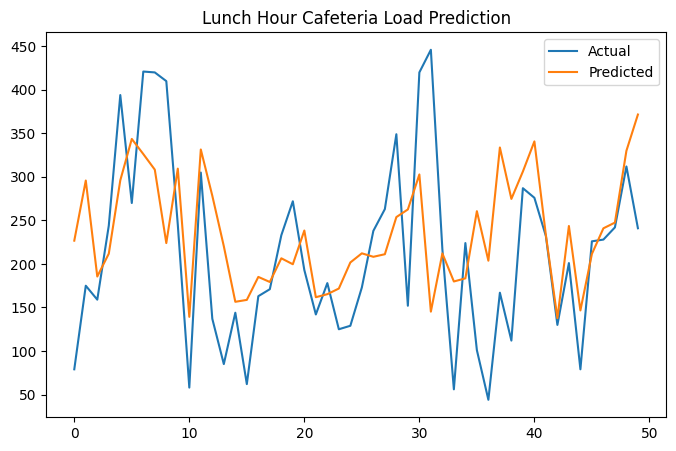

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(pred[:50], label="Predicted")

plt.title("Lunch Hour Cafeteria Load Prediction")
plt.legend()

plt.show()

In [7]:
import time
import numpy as np

print("Real-time Cafeteria Load Prediction\n")

for i in range(10):

    sample = X_test.sample(1)

    prediction = model.predict(sample)[0]

    print("Temp:", round(sample['temp'].values[0],2),
          "Humidity:", round(sample['hum'].values[0],2),
          "Hour:", sample['hr'].values[0],
          "Predicted Load:", int(prediction))

    time.sleep(2)

Real-time Cafeteria Load Prediction

Temp: 0.54 Humidity: 0.52 Hour: 14 Predicted Load: 267
Temp: 0.74 Humidity: 0.58 Hour: 13 Predicted Load: 266
Temp: 0.4 Humidity: 0.47 Hour: 11 Predicted Load: 214
Temp: 0.54 Humidity: 0.83 Hour: 11 Predicted Load: 195
Temp: 0.64 Humidity: 0.29 Hour: 12 Predicted Load: 244
Temp: 0.52 Humidity: 0.83 Hour: 12 Predicted Load: 196
Temp: 0.74 Humidity: 0.37 Hour: 13 Predicted Load: 317
Temp: 0.7 Humidity: 0.58 Hour: 13 Predicted Load: 256
Temp: 0.62 Humidity: 0.43 Hour: 11 Predicted Load: 272
Temp: 0.44 Humidity: 0.47 Hour: 14 Predicted Load: 199


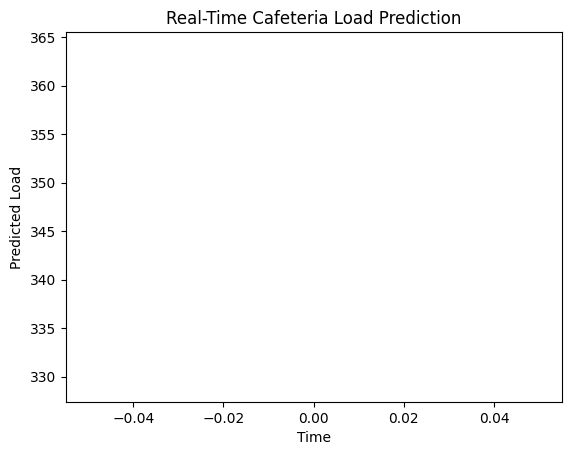

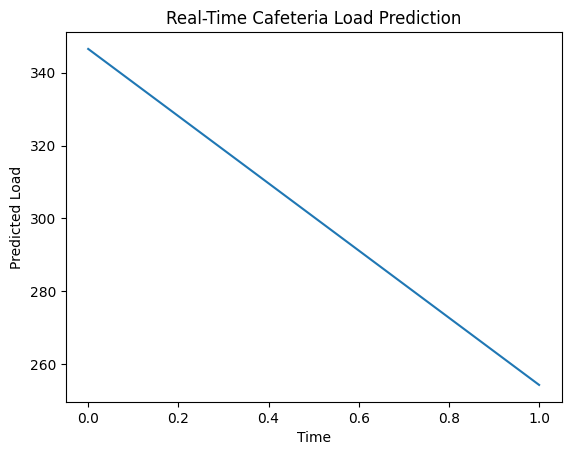

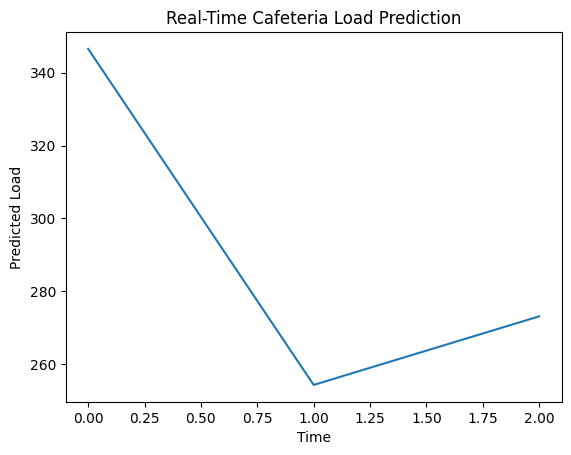

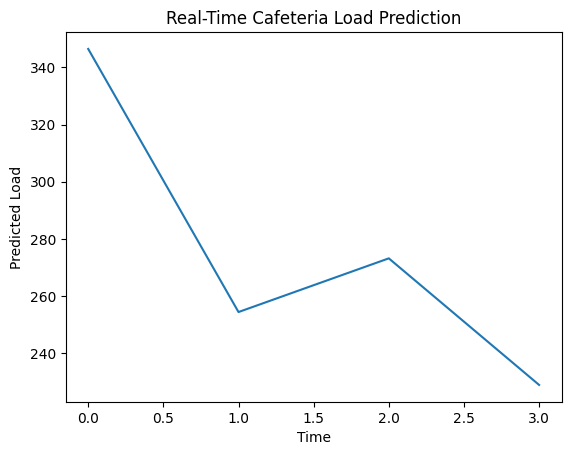

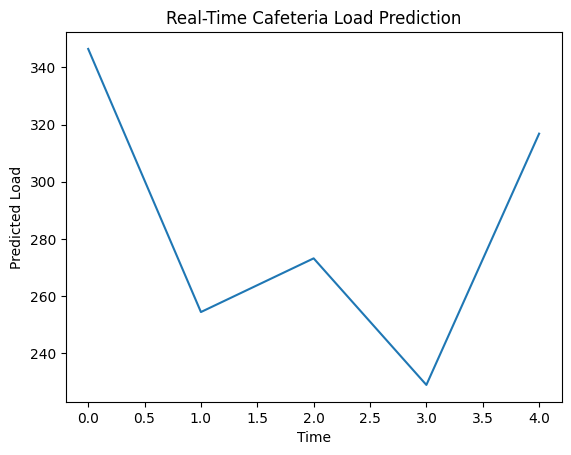

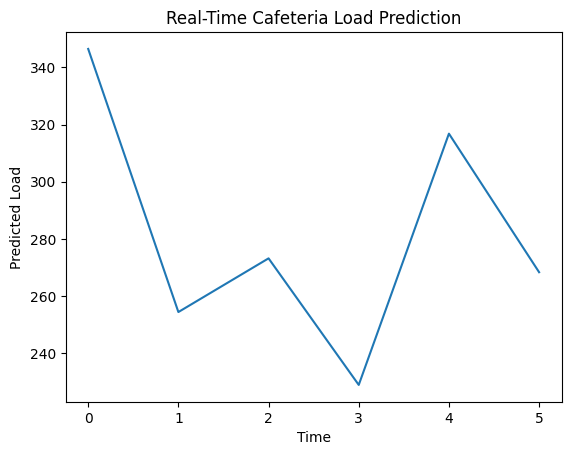

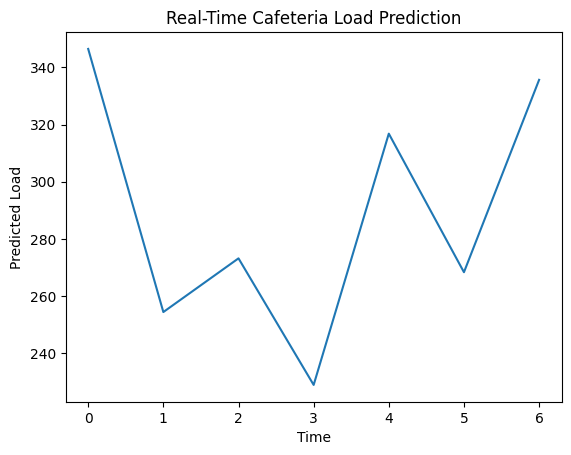

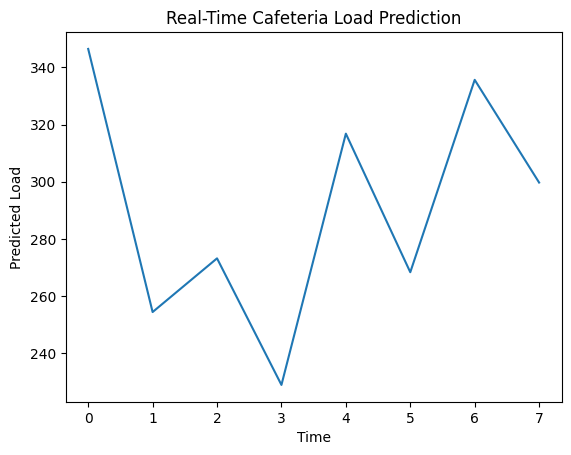

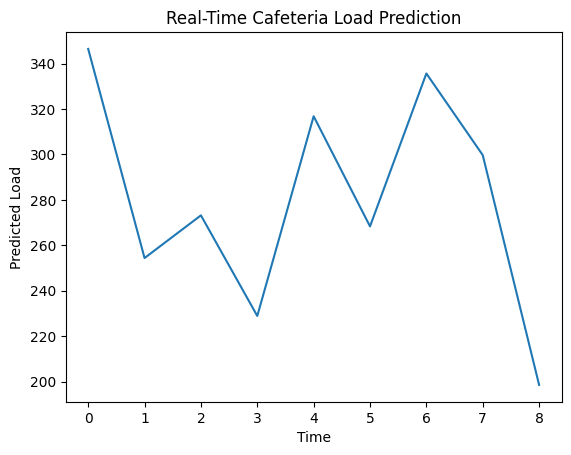

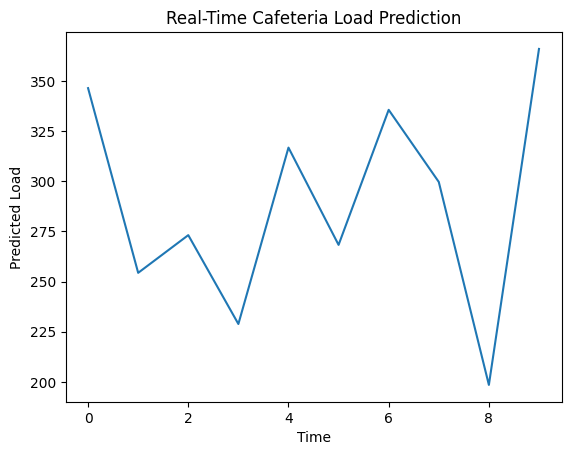

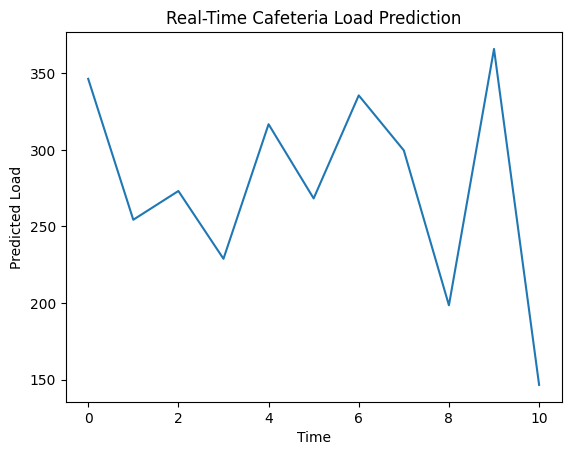

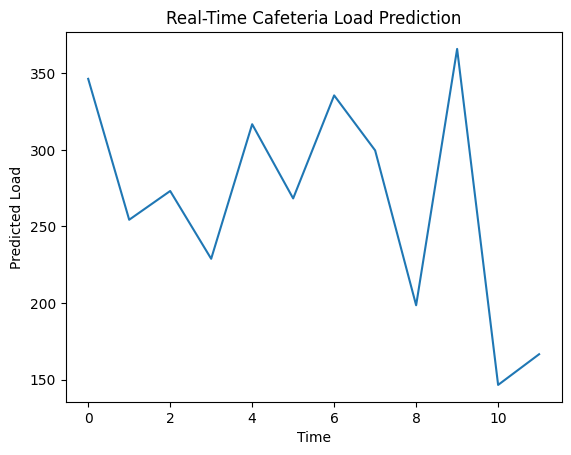

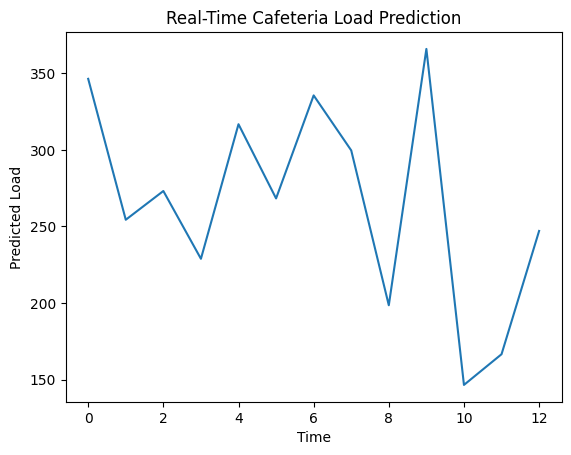

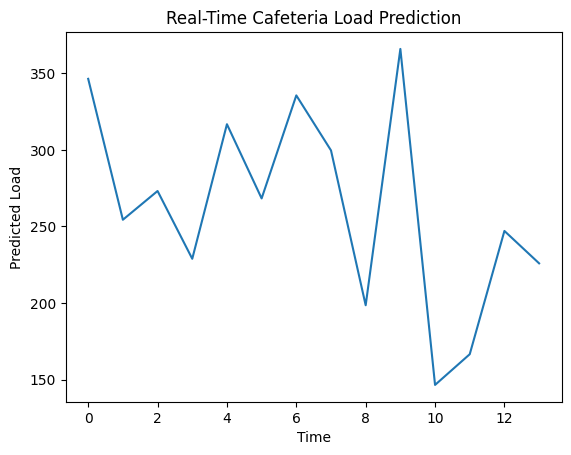

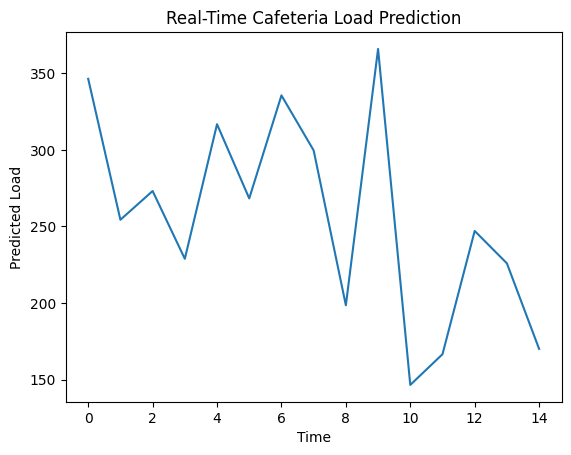

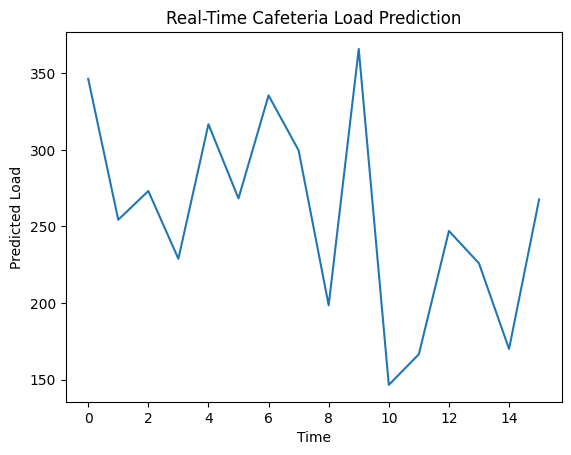

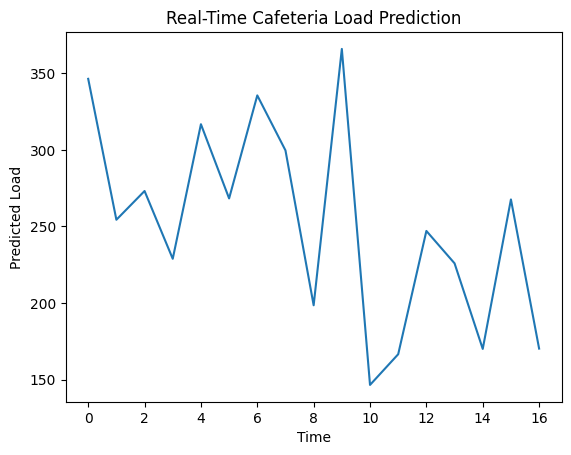

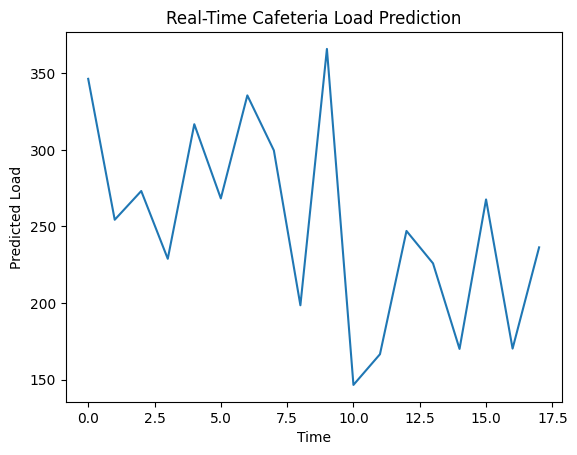

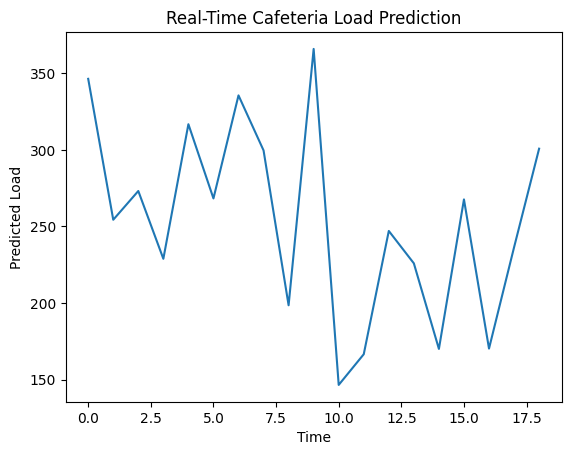

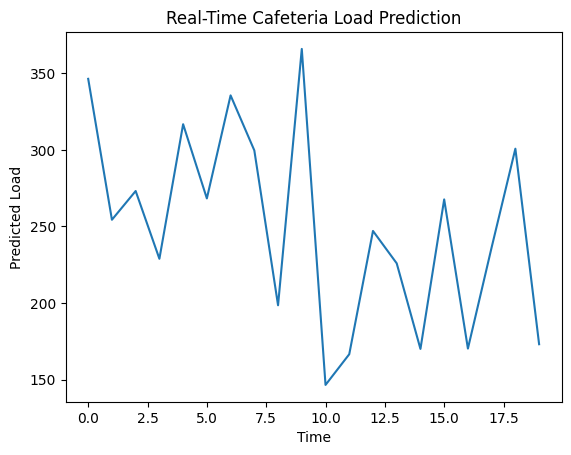

In [8]:
import matplotlib.pyplot as plt
import time

predictions = []

plt.ion()

for i in range(20):

    sample = X_test.sample(1)

    prediction = model.predict(sample)[0]

    predictions.append(prediction)

    plt.clf()

    plt.plot(predictions)

    plt.title("Real-Time Cafeteria Load Prediction")
    plt.xlabel("Time")
    plt.ylabel("Predicted Load")

    plt.pause(0.5)

plt.ioff()